# Neutral proatomic density and pairwise IAS-proxy workflows

This notebook demonstrates the public `atomref 0.2.x` density and pairwise APIs. The profiles are frozen, isolated, neutral, spherical proatoms—not molecular electron densities. The pairwise results are useful reference-atom models, but neither mode is an exact molecular QTAIM zero-flux surface or critical point.

**Prerequisites.** Install `atomref[notebook]` for Matplotlib support. Familiarity with scalar function calls and ordinary radial-density plots is sufficient; the scientific assumptions and mode distinction are introduced before use.

## Setup

The package has no runtime plotting dependency. This release notebook uses the optional `notebook` extra for Matplotlib and selects its non-interactive backend so the same cells run deterministically in CI.

In [1]:
from __future__ import annotations

import math
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "atomref").is_dir():
    for candidate in (ROOT.parent, ROOT.parent.parent):
        if (candidate / "src" / "atomref").is_dir():
            ROOT = candidate
            break
if not (ROOT / "src" / "atomref").is_dir():
    raise RuntimeError("Run this notebook from the atomref repository checkout")
sys.path.insert(0, str(ROOT / "src"))

import atomref as ar
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

print(f"atomref {ar.__version__}; matplotlib {matplotlib.__version__}")

atomref 0.2.1; matplotlib 3.11.0


## Dataset discovery and provenance

The radial dataset uses the same registry and `get_builtin_set()` dispatcher as scalar tables. Notice the typed radial payload, complete H–Lr coverage, exact upstream release and dataset identity, 20-bohr public limit, and separate CC BY 4.0 data license.

In [2]:
quantity = ar.get_quantity_info("proatomic_density")
info = ar.get_proatomic_density_set_info()
dataset = ar.get_builtin_set(info.ref)
storage = info.storage

print(f"Quantity: {quantity.quantity!r}; domain={quantity.domain!r}; units={quantity.units!r}")
print(f"Dataset: {info.ref.set_id}")
print(f"Payload: {type(dataset).__name__}; profiles={info.coverage.n_values}; grid rows={len(dataset.radii)}")
print(f"Source: {storage['source_project']} {storage['source_release']}, {storage['source_dataset_id']}")
print(f"Method: {info.method_summary}")
print(f"Public radius limit: {storage['public_max_radius_bohr']} bohr; data license: {storage['data_license']}")
print("DOIs:", ", ".join(reference.doi for reference in info.references if reference.doi))

Quantity: 'proatomic_density'; domain='element'; units='electron/bohr^3'
Dataset: pbe0_sfx2c_dyallv4z_h-lr_neutral_v2
Payload: ElementRadialSet; profiles=103; grid rows=1127
Source: atomref-proatoms 2.0.0, pbe0_sfx2c_dyallv4z_h-lr_spherical_v2
Method: PBE0 self-consistent spherical fractional-occupation UKS with spin-free one-electron X2C and the dyall-v4z basis.
Public radius limit: 20.0 bohr; data license: CC BY 4.0
DOIs: 10.5281/zenodo.21291021, 10.5281/zenodo.21291022


## Profile retrieval and scalar evaluation

Profiles are immutable views on the shared grid. Radius input and density output units are independent: the two evaluations below use different radius units for the same physical point, while the final value requests electron/Å³ explicitly.

In [3]:
oxygen = ar.get_proatomic_density_profile("O")
assert oxygen is not None
radius_angstrom = 0.75
radius_bohr = radius_angstrom / ar.BOHR_TO_ANGSTROM
rho_native_from_angstrom = oxygen(radius_angstrom)
rho_native_from_bohr = oxygen(radius_bohr, radius_unit="bohr")
rho_angstrom = oxygen(
    radius_bohr, radius_unit="bohr", density_unit="electron/angstrom^3"
)
assert math.isclose(rho_native_from_angstrom, rho_native_from_bohr, rel_tol=1e-14)

print(f"Profile: {oxygen.symbol}; Z={oxygen.atomic_number}; contract={oxygen.interpolation_contract}")
print(f"rho_O(0.75 Å) = {rho_native_from_angstrom:.12g} electron/bohr^3")
print(f"same point       = {rho_native_from_bohr:.12g} electron/bohr^3")
print(f"converted output = {rho_angstrom:.12g} electron/angstrom^3")

Profile: O; Z=8; contract=loglog_positive_bracketed_v1
rho_O(0.75 Å) = 0.114179969338 electron/bohr^3
same point       = 0.114179969338 electron/bohr^3
converted output = 0.770524625676 electron/angstrom^3


## Radial-density profiles

A logarithmic density axis exposes both the compact core and long neutral tail. These curves are isolated-atom references sampled through the public scalar evaluator; they are not densities of atoms embedded in a molecule.

Plotted C and O profiles from 0.01 through 10 bohr.


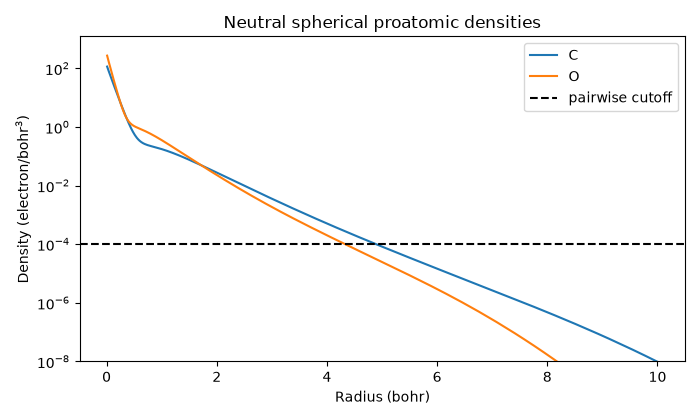

In [4]:
radii_bohr = [10 ** (-2 + 3 * index / 300) for index in range(301)]
figure, axis = plt.subplots(figsize=(7.0, 4.2))
for symbol in ("C", "O"):
    profile = ar.get_proatomic_density_profile(symbol)
    assert profile is not None
    values = [profile(radius, radius_unit="bohr") for radius in radii_bohr]
    axis.plot(radii_bohr, values, label=symbol)
axis.axhline(ar.PROATOMIC_TAIL_CUTOFF, color="black", linestyle="--", label="pairwise cutoff")
axis.set(xlabel="Radius (bohr)", ylabel=r"Density (electron/bohr$^3$)", title="Neutral spherical proatomic densities")
axis.set_yscale("log")
axis.set_ylim(1e-8, None)
axis.legend()
figure.tight_layout()
print("Plotted C and O profiles from 0.01 through 10 bohr.")
figure

## Ordinary heteronuclear pair: boundary and minimum

For C–O at 1.5 bohr the fixed cutoff contours overlap. The stable default `boundary` balances the two proatomic contributions; the optional `minimum` instead selects a resolved valley in their sum. The distinct coordinates are expected because the modes answer different questions.

In [5]:
atom_a, atom_b, distance = "C", "O", 1.5
boundary = ar.estimate_proatomic_boundary(atom_a, atom_b, distance, distance_unit="bohr")
minimum = ar.estimate_promolecular_density_minimum(atom_a, atom_b, distance, distance_unit="bohr")
dispatched = ar.estimate_ias_position(atom_a, atom_b, distance, mode="boundary", distance_unit="bohr")
assert boundary is not None and minimum is not None and dispatched == boundary

for label, result in (("boundary", boundary), ("minimum", minimum)):
    print(f"{label:>8}: method={result.method}; status={result.status}; x_A={result.position_from_a:.12f} bohr; rho_sum={result.rho_sum:.12g}")
print(f"coordinate difference: {abs(boundary.position_from_a - minimum.position_from_a):.12f} bohr")
print(f"cutoff={boundary.cutoff_density:g} {boundary.density_unit}; regime={boundary.cutoff_regime}")

boundary: method=equal_proatom_density; status=ok; x_A=0.556215252014 bohr; rho_sum=0.828138349302
 minimum: method=promolecular_density_minimum; status=ok; x_A=0.611760239317 bohr; rho_sum=0.801643412838
coordinate difference: 0.055544987303 bohr
cutoff=0.0001 electron/bohr^3; regime=overlap


## Component and summed line densities

The dashed boundary line crosses where the C and O contributions are equal. The dotted minimum line sits at the valley of their sum, so it need not divide the component densities equally. Coordinates are measured from atom A (C) toward atom B (O). Swapping the pair maps each coordinate `x` to `R - x` and exchanges the C/O component fields.

The component crossing and summed-density minimum are marked separately.


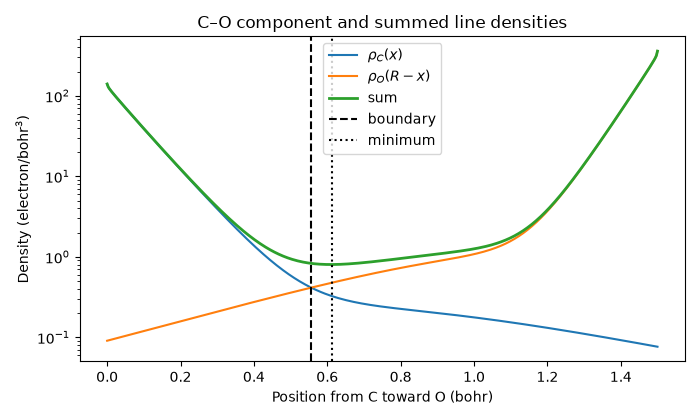

In [6]:
profile_a = ar.get_proatomic_density_profile(atom_a)
profile_b = ar.get_proatomic_density_profile(atom_b)
assert profile_a is not None and profile_b is not None
positions = [distance * index / 500 for index in range(501)]
rho_a_values = [profile_a(x, radius_unit="bohr") for x in positions]
rho_b_values = [profile_b(distance - x, radius_unit="bohr") for x in positions]
rho_sum_values = [left + right for left, right in zip(rho_a_values, rho_b_values)]

figure, axis = plt.subplots(figsize=(7.0, 4.2))
axis.plot(positions, rho_a_values, label=r"$\rho_C(x)$")
axis.plot(positions, rho_b_values, label=r"$\rho_O(R-x)$")
axis.plot(positions, rho_sum_values, label="sum", linewidth=2)
axis.axvline(boundary.position_from_a, color="black", linestyle="--", label="boundary")
axis.axvline(minimum.position_from_a, color="black", linestyle=":", label="minimum")
axis.set(xlabel="Position from C toward O (bohr)", ylabel=r"Density (electron/bohr$^3$)", title="C–O component and summed line densities")
axis.set_yscale("log")
axis.legend()
figure.tight_layout()
print("The component crossing and summed-density minimum are marked separately.")
figure

## Exact homonuclear midpoint

For identical atoms, exchange symmetry fixes both modes at exactly `R/2`; raw interpolation-scale shell structure is not allowed to choose an off-centre separator.

In [7]:
homonuclear_distance = 3.0
o_o_boundary = ar.estimate_proatomic_boundary("O", "O", homonuclear_distance, distance_unit="bohr")
o_o_minimum = ar.estimate_promolecular_density_minimum("O", "O", homonuclear_distance, distance_unit="bohr")
assert o_o_boundary is not None and o_o_minimum is not None
assert o_o_boundary.position_from_a == homonuclear_distance / 2
assert o_o_minimum.position_from_a == homonuclear_distance / 2
print(f"O–O boundary: method={o_o_boundary.method}; x_A={o_o_boundary.position_from_a} bohr")
print(f"O–O minimum:  method={o_o_minimum.method}; x_A={o_o_minimum.position_from_a} bohr")

O–O boundary: method=homonuclear_midpoint; x_A=1.5 bohr
O–O minimum:  method=homonuclear_midpoint; x_A=1.5 bohr


## Low-density gap

At a long H–O separation the two `1e-4 electron/bohr^3` contours no longer overlap. Boundary mode returns the geometric midpoint of the contour gap. Minimum mode does not search unconstrained tails and explicitly returns a `low_density_gap` non-result.

In [8]:
gap_boundary = ar.estimate_proatomic_boundary("H", "O", 12.0, distance_unit="bohr")
gap_minimum = ar.estimate_promolecular_density_minimum("H", "O", 12.0, distance_unit="bohr")
assert gap_boundary is not None and gap_minimum is not None
print(f"boundary: method={gap_boundary.method}; status={gap_boundary.status}; x_A={gap_boundary.position_from_a:.12f} bohr")
print(f"minimum:  method={gap_minimum.method}; status={gap_minimum.status}; x_A={gap_minimum.position_from_a}")
print(f"cutoff-contour separation: {gap_boundary.contour_separation:.12f} bohr")

boundary: method=cutoff_gap_midpoint; status=low_density_gap; x_A=5.897488624776 bohr
minimum:  method=none; status=low_density_gap; x_A=None
cutoff-contour separation: 3.538953155071 bohr


## No resolved interior minimum

A short H–U example shows another valid diagnostic result. The cutoff-bounded search finds no strict-interior valley resolved at the declared `0.01 bohr` scale, so minimum mode returns typed status and provenance without inventing a coordinate or falling back to boundary mode.

In [9]:
unresolved = ar.estimate_promolecular_density_minimum("H", "U", 1.58, distance_unit="bohr")
assert unresolved is not None
print(f"method={unresolved.method}; status={unresolved.status}; x_A={unresolved.position_from_a}")
print(f"resolution={unresolved.search_resolution} bohr; converged={unresolved.search_converged}; passes={unresolved.search_passes}")
print(f"dataset={unresolved.dataset_id}")
print(f"interpolation={unresolved.interpolation_contract}")
print(f"pairwise contract={unresolved.pairwise_contract}")

method=none; status=no_resolved_interior_minimum; x_A=None
resolution=0.01 bohr; converged=True; passes=2
dataset=pbe0_sfx2c_dyallv4z_h-lr_neutral_v2
interpolation=loglog_positive_bracketed_v1
pairwise contract=neutral_proatom_pairwise_cutoff_1e-4_resolution_0.01_v1


## What this demonstrated: mode selection, statuses, and limitations

Use `boundary`—the dispatcher default—for a stable neutral-proatom divider in geometry, Voronoi/Laguerre calibration, or related reference-atom workflows. Use `minimum` only when a cutoff-bounded promolecular line-density valley is the intended proxy and a resolution-limited non-result is acceptable. Minimum mode never silently falls back to boundary mode.

Pair distances must satisfy `0 < R <= 20 bohr`; distance and density units are independent, and coordinates are reported from atom A toward atom B. Reversing A/B maps primary and alternative coordinates `x` to `R - x`, swaps component fields, and relabels dominance; orientation-independent status and diagnostics remain equivalent. The fixed per-atom cutoff is exactly `1e-4 electron/bohr^3`. The practical minimum resolution is `0.01 bohr`; sub-resolution minima are deliberately coalesced or rejected. Inspect `method`, `status`, `position_from_a`, `dominant_atom`, `ambiguous`, and search diagnostics instead of assuming every valid request has a coordinate. Explicit statuses include `low_density_gap`, `one_atom_dominates`, `no_resolved_interior_minimum`, `boundary_dominated`, `ambiguous_competing_minima`, and `search_unstable`.

The profiles cover neutral H–Lr only and are defined by the recorded PBE0/sf-X2C/dyall-v4z method, finite radial grid, sphericalization, and interpolation contract. There are no ions, vectorized or grid-density APIs, environment-dependent atoms, molecular densities, or exact QTAIM surfaces in this release.